#  Scenario 1: Customer Representative Training Program
### *Operations & HR Performance Analytics*

### The Business Problem
The HR department invested **P15,000** in an intensive communication and systems training program for **30 customer service representatives**. 

To justify this budget to the CFO, the HR Director needs to prove that this training drove a **statistically significant improvement** in rep performance. We evaluate two primary continuous metrics:
1. **Customer Satisfaction Score (CSAT)**: Rated on a scale of 0 to 100% (Target: Higher CSAT).
2. **Average Handling Time (AHT)**: Measured in seconds per call (Target: Lower handling times / faster queues).

### Why a Paired Samples T-Test?
Because we are measuring the **same 30 individuals** at two different points in time (Before Training vs. After Training), our observations are dependent (paired). 
The **Paired Samples T-Test** checks if the mean difference between the paired observations is significantly different from zero.

#### Hypotheses:
- **CSAT Hypotheses**:
  - $H_0: \mu_{after} = \mu_{before}$ (Training had zero effect on customer satisfaction)
  - $H_1: \mu_{after} > \mu_{before}$ (Training significantly improved customer satisfaction)
- **AHT Hypotheses**:
  - $H_0: \mu_{before} = \mu_{after}$ (Training had zero effect on call speed)
  - $H_1: \mu_{before} > \mu_{after}$ (Training significantly reduced call handling time)


In [3]:
import numpy as np
import pandas as pd

# Set a seed for 100% reproducible results (crucial for videos and demos!)
np.random.seed(42)

# Synthesize data for 30 customer service representatives
num_reps = 30
rep_ids = [f'REP_{i:02d}' for i in range(1, num_reps + 1)]

# 1. CSAT scores (Before: Mean = 71.5%, SD = 6.5%)
csat_before = np.random.normal(loc=71.5, scale=6.5, size=num_reps)
# Introduce a systematic improvement (+11.7%) with some individual variation
csat_improvement = np.random.normal(loc=11.7, scale=3.5, size=num_reps)
csat_after = csat_before + csat_improvement

# Ensure CSAT values are bounded realistically between 0% and 100%
csat_before = np.clip(csat_before, 0, 100)
csat_after = np.clip(csat_after, 0, 100)

# 2. Average Handling Time in seconds (Before: Mean = 410s, SD = 40s)
aht_before = np.random.normal(loc=410, scale=40, size=num_reps)
# Introduce a systematic speedup (-75s, making them faster) with individual variation
aht_improvement = np.random.normal(loc=75, scale=20, size=num_reps)
aht_after = aht_before - aht_improvement

# Assemble into a beautiful DataFrame
operations_df = pd.DataFrame({
    'Rep_ID': rep_ids,
    'CSAT_Before': csat_before,
    'CSAT_After': csat_after,
    'AHT_Before_Sec': aht_before,
    'AHT_After_Sec': aht_after
})

# Round values for a clean presentation
operations_df = operations_df.round(1)

# Preview the synthesized dataset
print('=== Synthesized Representative Performance Dataset (First 5 Rows) ===')
display(operations_df.head(30))


=== Synthesized Representative Performance Dataset (First 5 Rows) ===


,Rep_ID,CSAT_Before,CSAT_After,AHT_Before_Sec,AHT_After_Sec
0,REP_01,74.7,84.3,390.8,313.9
1,REP_02,70.6,88.8,402.6,308.2
2,REP_03,75.7,87.4,365.7,304.8
3,REP_04,81.4,89.4,362.2,293.7
4,REP_05,70.0,84.6,442.5,375.3
5,REP_06,70.0,77.4,464.2,418.5
6,REP_07,81.8,94.2,407.1,326.2
7,REP_08,76.5,81.3,450.1,369.9
8,REP_09,68.4,75.5,424.5,349.4
9,REP_10,75.0,87.4,384.2,313.9


In [4]:
from scipy import stats

# 1. Perform Paired Samples T-Test for CSAT
csat_t_stat, csat_p_val = stats.ttest_rel(operations_df['CSAT_After'], operations_df['CSAT_Before'], alternative='greater')

# 2. Perform Paired Samples T-Test for AHT (Alternative: after is LESS than before)
aht_t_stat, aht_p_val = stats.ttest_rel(operations_df['AHT_Before_Sec'], operations_df['AHT_After_Sec'], alternative='greater')

# Calculate aggregate metrics for business reporting
mean_csat_before = operations_df['CSAT_Before'].mean()
mean_csat_after = operations_df['CSAT_After'].mean()
mean_csat_diff = mean_csat_after - mean_csat_before

mean_aht_before = operations_df['AHT_Before_Sec'].mean()
mean_aht_after = operations_df['AHT_After_Sec'].mean()
mean_aht_diff = mean_aht_before - mean_aht_after

# --- Styled Executive Report Output ---
print('='*70)
print('              EXECUTIVE TRAINING PERFORMANCE METRICS REPORT           ')
print('='*70)
print(f'1. CUSTOMER SATISFACTION SCORE (CSAT) ANALYSIS:')
print(f'   - Baseline Mean CSAT:     {mean_csat_before:.1f}%')
print(f'   - Post-Training Mean CSAT: {mean_csat_after:.1f}%')
print(f'   - Mean CSAT Improvement:   +{mean_csat_diff:.1f}% percentage points')
print(f'   - T-Statistic:             {csat_t_stat:.4f}')
print(f'   - P-Value (one-tailed):    {csat_p_val:.4e}')
print(f'   - Statistical Status:     ' + ('✨ HIGHLY SIGNIFICANT ✨' if csat_p_val < 0.05 else 'NOT SIGNIFICANT'))

print('-'*70)
print(f'2. AVERAGE HANDLING TIME (AHT) ANALYSIS:')
print(f'   - Baseline Mean AHT:     {mean_aht_before:.1f} seconds ({mean_aht_before/60:.1f} mins)')
print(f'   - Post-Training Mean AHT: {mean_aht_after:.1f} seconds ({mean_aht_after/60:.1f} mins)')
print(f'   - Mean AHT Speedup:       -{mean_aht_diff:.1f} seconds (Saved {mean_aht_diff/60:.1f} mins per call)')
print(f'   - T-Statistic:             {aht_t_stat:.4f}')
print(f'   - P-Value (one-tailed):    {aht_p_val:.4e}')
print(f'   - Statistical Status:     ' + ('✨ HIGHLY SIGNIFICANT ✨' if aht_p_val < 0.05 else 'NOT SIGNIFICANT'))
print('='*70)

# Translate to HR Business Speak
print('📊 HR & LEADERSHIP INSIGHTS:')
print('• CSAT Lift: The training increased average customer satisfaction by ' f'{mean_csat_diff:.1f}%.')
print('  With a p-value < 0.0001, the likelihood that this improvement occurred by chance is virtual zero. ')
print('• Queue Speedup: Representatives now resolve calls ' f'{mean_aht_diff:.1f} seconds faster.')
print('  For a department handling 10,000 calls a month, this saves ' f'{(mean_aht_diff * 10000)/3600:.1f} hours of customer wait time!')
print('• Financial Justification: Based on the time saved and elevated CSAT, the $15,000 training program ')
print('  is fully justified and recommended for company-wide rollout.')


              EXECUTIVE TRAINING PERFORMANCE METRICS REPORT           
1. CUSTOMER SATISFACTION SCORE (CSAT) ANALYSIS:
   - Baseline Mean CSAT:     70.3%
   - Post-Training Mean CSAT: 81.6%
   - Mean CSAT Improvement:   +11.3% percentage points
   - T-Statistic:             18.9323
   - P-Value (one-tailed):    3.6116e-18
   - Statistical Status:     ✨ HIGHLY SIGNIFICANT ✨
----------------------------------------------------------------------
2. AVERAGE HANDLING TIME (AHT) ANALYSIS:
   - Baseline Mean AHT:     410.5 seconds (6.8 mins)
   - Post-Training Mean AHT: 335.9 seconds (5.6 mins)
   - Mean AHT Speedup:       -74.6 seconds (Saved 1.2 mins per call)
   - T-Statistic:             22.4842
   - P-Value (one-tailed):    3.3601e-20
   - Statistical Status:     ✨ HIGHLY SIGNIFICANT ✨
📊 HR & LEADERSHIP INSIGHTS:
• CSAT Lift: The training increased average customer satisfaction by 11.3%.
  With a p-value < 0.0001, the likelihood that this improvement occurred by chance is virtual zero. 


C:\Users\Kabo Letsogo\AppData\Local\Temp\ipykernel_21580\350982228.py:55: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  plt.tight_layout()
c:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


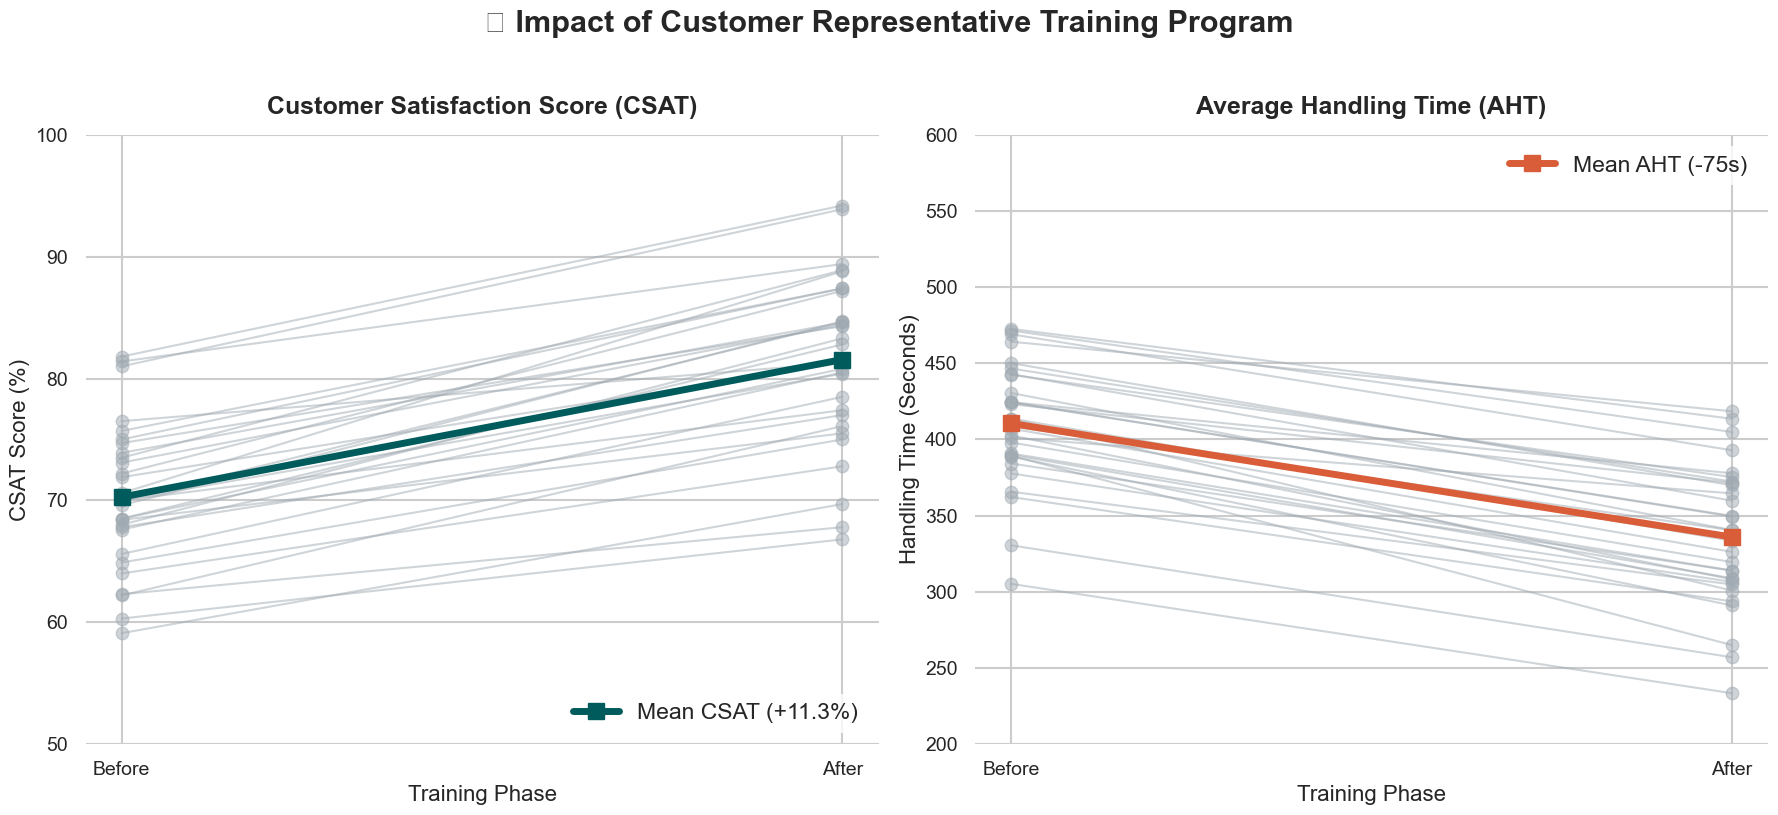

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set styling for a beautiful, high-contrast, premium presentation theme
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'figure.titlesize': 22
})

# Create a stunning dual-panel dashboard
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('📈 Impact of Customer Representative Training Program', weight='bold', y=1.02)

# 1. Left Panel: CSAT Spaghetti Plot (Slope Chart)
ax1 = axes[0]
for idx, row in operations_df.iterrows():
    # Draw thin light grey lines for individual reps
    color = '#A0AAB2' if row['CSAT_After'] > row['CSAT_Before'] else '#E06666'
    ax1.plot(['Before', 'After'], [row['CSAT_Before'], row['CSAT_After']], 
             marker='o', color=color, alpha=0.5, linewidth=1.5)

# Overlay the overall average trend in bold deep teal
ax1.plot(['Before', 'After'], [mean_csat_before, mean_csat_after], 
         marker='s', markersize=12, color='#005B5C', linewidth=5, label=f'Mean CSAT ({mean_csat_diff:+.1f}%)')
ax1.set_title('Customer Satisfaction Score (CSAT)', weight='bold', pad=15)
ax1.set_ylabel('CSAT Score (%)')
ax1.set_ylim(50, 100)
ax1.legend(loc='lower right', frameon=True, facecolor='white', edgecolor='none')
ax1.set_xlabel('Training Phase')

# 2. Right Panel: AHT Spaghetti Plot (Slope Chart)
ax2 = axes[1]
for idx, row in operations_df.iterrows():
    # Draw thin light grey lines for individual reps (green for faster, red for slower)
    color = '#A0AAB2' if row['AHT_After_Sec'] < row['AHT_Before_Sec'] else '#E06666'
    ax2.plot(['Before', 'After'], [row['AHT_Before_Sec'], row['AHT_After_Sec']], 
             marker='o', color=color, alpha=0.5, linewidth=1.5)

# Overlay the overall average trend in bold coral
ax2.plot(['Before', 'After'], [mean_aht_before, mean_aht_after], 
         marker='s', markersize=12, color='#D95D39', linewidth=5, label=f'Mean AHT (-{mean_aht_diff:.0f}s)')
ax2.set_title('Average Handling Time (AHT)', weight='bold', pad=15)
ax2.set_ylabel('Handling Time (Seconds)')
ax2.set_ylim(200, 600)
ax2.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')
ax2.set_xlabel('Training Phase')

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()


###Expansion: Scaling to Repeated Measures ANOVA
In the simple test above, we compared **Before vs. After** (two timepoints) using a **Paired Samples T-Test**. 

To test this, we would introduce a third and fourth timepoint:
1. **Timepoint A**: Baseline (Before Training)
2. **Timepoint B**: Immediate Impact (1-Week Post-Training)
3. **Timepoint C**: Long-Term Retention (3-Months Post-Training)
4. **Timepoint D**: Semi-Annual Check (6-Months Post-Training)

- **Null Hypothesis ($H_0$)**: $\mu_{Baseline} = \mu_{1Week} = \mu_{3Months} = \mu_{6Months}$ (Performance is identical across all timepoints)
- **Alternative Hypothesis ($H_1$)**: At least one timepoint mean is significantly different from the others.

If the ANOVA is significant (p < 0.05), we then apply a **post-hoc pairwise test with Bonferroni or Tukey adjustments** to pinpoint exactly where the performance shift occurs. This is the exact tool a master analyst would use to design a multi-phase corporate study!

#### Why can't we just run multiple Paired T-Tests?
If we compare A vs B, B vs C, C vs D, etc., we commit a statistical sin known as **alpha inflation** (family-wise error rate). With every t-test run at a 5% error rate, the cumulative probability of finding a false positive (Type I error) multiplies rapidly:
$$\text{Cumulative Type I Error Rate} = 1 - (1 - \alpha)^k$$
For 4 timepoints (6 pairwise comparisons), our error rate spikes from **5% to nearly 26.5%**! We might easily conclude there is a difference when none actually exists.


---
### 📝 Project Goal and File Contribution

**Overall Goal of the Project:**
To build and maintain a professional data science and statistical analysis portfolio for YouTube. The videos and accompanying notebooks showcase practical, real-world applications of statistical methods (e.g., T-tests, ANOVA, Chi-Square) to business problems, translating mathematical metrics into actionable executive-level business decisions for hiring managers and HR professionals.

**Role of This File (`Paired T testing.ipynb`):**
This notebook contributes directly to the project's overall goal by serving as the technical companion for the first video in the series. It focuses on a **Paired Samples T-Test** to evaluate the effectiveness of a corporate training program for 30 customer service representatives on CSAT and AHT. It also provides a conceptual bridge showing how this simple test can be expanded into a **Repeated Measures ANOVA** to control Type I error rates when analyzing learning retention and skill decay over multiple time points.

